# Cafe Sales Analysis

## Описание проекта

В этом проекте анализируются данные продаж кафе, содержащие информацию о транзакциях, такие как товары, цены, способы оплаты, локации и даты покупок.

**Цели проекта:**
- Очистить «грязные» данные (ошибки, пропуски, некорректные значения)
- Восстановить недостающие числовые значения через логические зависимости
- Провести разведочный анализ (EDA) и выявить закономерности в продажах

**Используемые инструменты:** `pandas`, `numpy`, `matplotlib`

**Датасет:** `dirty_cafe_sales.csv` — содержит намеренно «загрязнённые» данные продаж кафе.

## 1. Загрузка данных и первичный осмотр

Загружается датасет и анализируется его структура. Рассматриваются типы столбцов, количество строк, первые записи.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cafe_df = pd.read_csv('/content/drive/MyDrive/Датасеты/Cafe/dirty_cafe_sales.csv')

cafe_df.head(3)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19


## 2. Приведение названий столбцов к единому виду

Как видно из результатов вышел, колонки не приведены к стандартному "змеиному" регистру. Все названия колонок приводятся к нижнему регистру, убираются лишние пробелы, пробелы между словами заменяются на нижнее подчёркивание.

In [52]:
cafe_df.columns = cafe_df.columns.str.lower().str.strip().str.replace(' ', '_')
cafe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    10000 non-null  object
 1   item              9667 non-null   object
 2   quantity          9862 non-null   object
 3   price_per_unit    9821 non-null   object
 4   total_spent       9827 non-null   object
 5   payment_method    7421 non-null   object
 6   location          6735 non-null   object
 7   transaction_date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


В таблице 8 столбцов:


*   transaction_id - id транзакции;
*   item - наименование товара;
*   quantity - количество товара в чеке;
*   price_per_unit - цена за еденицу товара;
*   total_spent - итоговая стоимость;
*   payment_method - способ оплаты;
*   location - тип заказа (Takeaway (на вынос)/ In-store (в магазине));
*   transaction_date - дата транзакции.


Все стоблцы имеют тип данных `object`, однако такие столбцы как quantity, price_per_unit, total_spent являются числовыми. Несоответствие типов данных говорит о том, что в столбцах есть текстовые значения.






## 3. Очистка числовых столбцов

Производится анализ уникальных значений столбцов с целью определения какие строковые данные есть в столбцах и для чего они нужны.

In [53]:
numeric_columns = ['quantity', 'price_per_unit', 'total_spent']

for i in numeric_columns:
  print(f'{i}: {cafe_df[i].unique()}')

quantity: ['2' '4' '5' '3' '1' 'ERROR' 'UNKNOWN' nan]
price_per_unit: ['2.0' '3.0' '1.0' '5.0' '4.0' '1.5' nan 'ERROR' 'UNKNOWN']
total_spent: ['4.0' '12.0' 'ERROR' '10.0' '20.0' '9.0' '16.0' '15.0' '25.0' '8.0' '5.0'
 '3.0' '6.0' nan 'UNKNOWN' '2.0' '1.0' '7.5' '4.5' '1.5']


Столбцы `quantity`, `price_per_unit` и `total_spent` содержат строковые `'ERROR'` и `'UNKNOWN'`. Это слова-заглушки, которые сигнализируют об ошибках во время сбора данных (например, произошел сбой в системе и данные о количестве товаров не записались в базу данных). Столбцы со строковыми значениями автоматически получают тип данных `object`, поэтому строковые данные заменяются на `NaN`, что позволяет конвертировать столбцы в тип `float` для дальнейших вычислений.

In [54]:
cafe_df[numeric_columns] = cafe_df[numeric_columns].replace(['ERROR', 'UNKNOWN'], np.nan).astype('float')

for i in numeric_columns:
  print(f'{i}: {cafe_df[i].unique()}')

quantity: [ 2.  4.  5.  3.  1. nan]
price_per_unit: [2.  3.  1.  5.  4.  1.5 nan]
total_spent: [ 4.  12.   nan 10.  20.   9.  16.  15.  25.   8.   5.   3.   6.   2.
  1.   7.5  4.5  1.5]


In [55]:
cafe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    10000 non-null  object 
 1   item              9667 non-null   object 
 2   quantity          9521 non-null   float64
 3   price_per_unit    9467 non-null   float64
 4   total_spent       9498 non-null   float64
 5   payment_method    7421 non-null   object 
 6   location          6735 non-null   object 
 7   transaction_date  9841 non-null   object 
dtypes: float64(3), object(5)
memory usage: 625.1+ KB


## 4. Очистка и преобразование дат

Столбец `transaction_date` скорее всего также содержатся случайные строковые значения, для их нахождения используется альтернативный подход. Для начала выполняется попытка преобразования столбца с датами в формат datetime с параметром `errors='coerce'`, благодаря чему все значения, которые не удалось преобразовать, становятся `NaT`. Затем создается булева маска, отмечающая эти "не даты" как `True`, и с её помощью фильтруется исходный DataFrame для отображения только уникальных проблемных значений.


In [56]:
not_date_mask = pd.to_datetime(cafe_df['transaction_date'], errors='coerce').isna()
cafe_df.loc[not_date_mask, 'transaction_date'].unique()

array(['ERROR', nan, 'UNKNOWN'], dtype=object)

С помощью этого же метода можно заменить случайные значения на `NaT`.

In [57]:
cafe_df['transaction_date'] = pd.to_datetime(cafe_df['transaction_date'], errors='coerce')

Столбец еще раз проверяется на наличие слов-заглушек.

In [58]:
not_date_mask = pd.to_datetime(cafe_df['transaction_date'], errors='coerce').isna()
cafe_df.loc[not_date_mask, 'transaction_date'].unique()

<DatetimeArray>
['NaT']
Length: 1, dtype: datetime64[ns]

Как видно из результатов, данные были преобразованы в формат даты и времени а все пропуски теперь обозначаются как `NaT`.

## 5. Очистка текстовых столбцов

Аналогичным образом очищаются текстовые столбцы: `item`, `payment_method`, `location`. Значения-заглушки также заменяются на `NaN`, чтобы в дальнейшем корректно обработать пропуски.

In [59]:
text_columns = ['item', 'payment_method', 'location']

for val in text_columns:
  print(f'{val}: {cafe_df[val].unique()}')

item: ['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea']
payment_method: ['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]
location: ['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']


In [60]:
cafe_df[text_columns] = cafe_df[text_columns].replace(['UNKNOWN', 'ERROR'], np.nan)

for val in text_columns:
  print(f'{val}: {cafe_df[val].unique()}')

item: ['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' nan 'Sandwich' 'Juice' 'Tea']
payment_method: ['Credit Card' 'Cash' nan 'Digital Wallet']
location: ['Takeaway' 'In-store' nan]


## 6. Проверка на дубликаты и оценка пропусков

Проверяется наличие полностью дублирующихся строк.

In [61]:
cafe_df.duplicated().sum()

np.int64(0)

Датафрейм не содержит одинаковых строк, удалять дубликаты не нужно.

Затем анализируется доля пропусков по каждому столбцу, что даёт понимание, насколько серьёзна проблема с качеством данных.

In [62]:
cafe_df.isna().mean().apply(lambda x: f'{x * 100:.2f}%')

,0
transaction_id,0.00%
item,9.69%
quantity,4.79%
price_per_unit,5.33%
total_spent,5.02%
payment_method,31.78%
location,39.61%
transaction_date,4.60%


Из результатов можно увидеть, что практически все столбцы датасета содержат пропуски.

Числовые поля (quantity — 4.79%, price_per_unit — 5.33%, total_spent — 5.02%, transaction_date — 4.60%) показывают сопоставимый уровень пропусков около 5%, что, вероятно, указывает на единый источник ошибок при записи транзакций. Эти пропуски частично устранимы, так как между тремя числовыми полями существует зависимость total_spent = quantity × price_per_unit, которая позволяет восстановить недостающее значение при наличии двух других.

Поле item (9.69%) имеет умеренный уровень пропусков. Часть из них также поддаётся восстановлению.

Наибольшую обеспокоенность вызывают столбцы payment_method (31.78%) и location (39.61%). Такой высокий процент пропусков делает невозможным полноценный анализ по этим измерениям — выводы об эффективности способов оплаты или географии продаж в таком случае будут основаны менее чем на 70% и 60% данных соответственно, что существенно снижает их достоверность.

## 7. Проверка целостности числовых данных

Между тремя числовыми столбцами существует зависимость:
`total_spent = quantity × price_per_unit`

Однако, для начала проверим сколько строк нарушают это соотношение


In [63]:
uncorrect_total_spent = cafe_df.query('quantity * price_per_unit != total_spent and quantity.notna() and price_per_unit.notna() and total_spent.notna()')

uncorrect_total_spent.size

0

Полученные результаты помогают убедиться, что все строки в датасете соотносятся как total_spent = quantity × price_per_unit

Далее проверяется не содержится ли в строках отрицательных значений. Наличие таких значений говорило бы о нарушении логики, так как не может быть отрицательных значений количества, цены и стоимости.

In [64]:
print(f'price_per_unit: {cafe_df[cafe_df["price_per_unit"]<=0].size}')
print(f'quantity: {cafe_df[cafe_df["quantity"]<=0].size}')
print(f'total_spent: {cafe_df[cafe_df["total_spent"]<=0].size}')

price_per_unit: 0
quantity: 0
total_spent: 0


Из полученных результатов можно сделать вывод, что логика не нарушена, отрицательных значений нет.

## 8. Восстановление пропущенных числовых значений

Для заполнения пропусков используется формула `total_spent = quantity × price_per_unit`
Если известны `quantity` и `price_per_unit`, то с их помощью можно вычислить `total_spent`.

Для начала нужно посмотреть сколько вообще строк можно заполнить таким образом.

In [65]:
# Восстановление total_spent
mask_miss_total_spent = (cafe_df['quantity'].notna() & cafe_df['price_per_unit'].notna() & cafe_df['total_spent'].isna())

print(f'Строк для восстановления total_spent: {cafe_df.loc[mask_miss_total_spent].shape[0]}')

Строк для восстановления total_spent: 462


Заполенение строк по формуле.

In [70]:
cafe_df.loc[mask_miss_total_spent, 'total_spent'] = cafe_df.loc[mask_miss_total_spent, 'quantity'] * cafe_df.loc[mask_miss_total_spent, 'price_per_unit']


Дополнительная проверка на то, что все строки для восстановления `total_spent` были заполнены

In [71]:
mask_miss_total_spent = (cafe_df['quantity'].notna() & cafe_df['price_per_unit'].notna() & cafe_df['total_spent'].isna())

print(f'Строк для восстановления total_spent: {cafe_df.loc[mask_miss_total_spent].shape[0]}')

Строк для восстановления total_spent: 0


Аналогично заполняются пропуски в остальных столбцах.

In [73]:
# Восстановление price_per_unit
mask_miss_price_per_unit = (cafe_df['quantity'].notna() & cafe_df['price_per_unit'].isna() & cafe_df['total_spent'].notna())

print(f'Строк для восстановления price_per_unit: {cafe_df.loc[mask_miss_price_per_unit].shape[0]}')

Строк для восстановления price_per_unit: 495


In [74]:
cafe_df.loc[mask_miss_price_per_unit, 'price_per_unit'] = cafe_df.loc[mask_miss_price_per_unit, 'total_spent'] / cafe_df.loc[mask_miss_price_per_unit, 'quantity']

In [75]:
mask_miss_price_per_unit = (cafe_df['quantity'].notna() & cafe_df['price_per_unit'].isna() & cafe_df['total_spent'].notna())

print(f'Строк для восстановления price_per_unit: {cafe_df.loc[mask_miss_price_per_unit].shape[0]}')

Строк для восстановления price_per_unit: 0


In [76]:
# Восстановление quantity
mask_miss_quantity = (cafe_df['quantity'].isna() & cafe_df['price_per_unit'].notna() & cafe_df['total_spent'].notna())

print(f'Строк для восстановления quantity: {cafe_df.loc[mask_miss_quantity].shape[0]}')

Строк для восстановления quantity: 441


In [77]:
cafe_df.loc[mask_miss_quantity, 'quantity'] = cafe_df.loc[mask_miss_quantity, 'total_spent'] / cafe_df.loc[mask_miss_quantity, 'price_per_unit']

In [78]:
mask_miss_quantity = (cafe_df['quantity'].isna() & cafe_df['price_per_unit'].notna() & cafe_df['total_spent'].notna())

print(f'Строк для восстановления quantity: {cafe_df.loc[mask_miss_quantity].shape[0]}')

Строк для восстановления quantity: 0


После выполнения расчётов проводилась повторная проверка на наличие пропусков в данных.

In [79]:
cafe_df.isna().mean().apply(lambda x: f'{x * 100:.2f}%')[numeric_columns]

,0
quantity,0.38%
price_per_unit,0.38%
total_spent,0.40%


 В результате доля пропусков в числовых колонках сократилась до уровня менее 0.4%, что позволило минимизировать потери данных перед дальнейшим анализом.

## 9. Удаление строк с неустранимыми пропусками в числовых полях

Строки, в которых не хватает двух и более числовых значений, восстановить невозможно. Они удаляются, чтобы гарантировать корректность всех последующих расчётов выручки. Их доля составляет менее 1% для каждого столбца от общего объёма данных, поэтому удаление не оказало значимого влияния на целостность выборки.

In [83]:
cafe_df = cafe_df.dropna(subset= numeric_columns)
print(f'Размер датасета после очистки: {cafe_df.shape}')

Размер датасета после очистки: (9942, 8)


,0
transaction_id,0.00%
item,9.69%
quantity,0.00%
price_per_unit,0.00%
total_spent,0.00%
payment_method,31.76%
location,39.63%
transaction_date,4.60%


In [84]:
cafe_df.isna().mean().apply(lambda x: f'{x * 100:.2f}%')

,0
transaction_id,0.00%
item,9.69%
quantity,0.00%
price_per_unit,0.00%
total_spent,0.00%
payment_method,31.76%
location,39.63%
transaction_date,4.60%


## 10. Восстановление названий товаров через цену

Каждый товар в меню имеет фиксированную цену.

In [87]:
item_price_df = cafe_df[['item', 'price_per_unit']].drop_duplicates().sort_values(by = 'price_per_unit')
item_price_df

,item,price_per_unit
2,Cookie,1.0
31,NaN,1.0
42,Tea,1.5
14,NaN,1.5
0,Coffee,2.0
30,NaN,2.0
6,NaN,3.0
1,Cake,3.0
17,Juice,3.0
151,NaN,4.0


Если `price_per_unit` соответствует одному конкретному товару, то пропуск в столбце `item` с соответствующей ценом можно заполнить названием этого товара.  

In [88]:
unique_price_item = {'Coffee': 2.0, 'Cookie': 1.0, 'Tea': 1.5, 'Salad': 5.0}

for i, j in unique_price_item.items():
  mask_cookie = (cafe_df['item'].isna()) & (cafe_df['price_per_unit'] == j)
  cafe_df.loc[mask_cookie, 'item'] = i

Товары с неуникальной ценой (Cake и Juice, Sandwich и Smoothie) восстановить невозможно, поэтому они остаются как `'Unknown'`.

In [92]:
cafe_df['item'] = cafe_df['item'].replace(np.nan, 'Unknown')

item_price_df = cafe_df[['item', 'price_per_unit']].drop_duplicates().sort_values(by = 'item')
item_price_df

,item,price_per_unit
1,Cake,3.0
0,Coffee,2.0
2,Cookie,1.0
17,Juice,3.0
3,Salad,5.0
7,Sandwich,4.0
5,Smoothie,4.0
14,Tea,1.5
6,Unknown,3.0
151,Unknown,4.0


## 11. Заполнение пропусков в категориальных столбцах

В отличие от числовых колонок, пропуски в payment_method и location невозможно восстановить логическим путём, так как эти признаки не имеют прямой математической связи с остальными полями и не могут быть вычислены на основе имеющихся данных. Доля пропусков в каждом из этих столбцов составляла около 40%, что является значительным объёмом. Удаление такого количества строк привело бы к потере большей части датасета и искажению результатов анализа.
В связи с этим было принято решение заполнить пропуски значением Unknown.

In [93]:
cafe_df['payment_method'].value_counts(dropna = False)
cafe_df['payment_method'] = cafe_df['payment_method'].replace(np.nan, 'Unknown')

In [94]:
cafe_df['location'].value_counts(dropna = False)
cafe_df['location'] = cafe_df['location'].replace(np.nan, 'Unknown')

## 12. Анализ распределения по датам

Для оценки качества данных и выявления возможных системных сбоев при регистрации продаж был проведён анализ распределения транзакций по временным периодам. Если бы в каком-то месяце или дне недели наблюдалось аномально низкое количество записей или полное их отсутствие, это могло бы указывать на проблемы в работе кассовой системы в конкретный период. Кроме того, равномерность распределения позволяет косвенно судить о стабильности работы кофейни и отсутствии длительных перерывов в деятельности.

In [100]:
print('Количество дней с покупками в месяце:')
for i in range(1,13):
  print(f'{i}: {len(cafe_df[cafe_df["transaction_date"].dt.month == i]["transaction_date"].unique())}')


Количество дней с покупками в месяце:
1: 31
2: 28
3: 31
4: 30
5: 31
6: 30
7: 31
8: 31
9: 30
10: 31
11: 30
12: 31


Анализ количества дней с покупками по месяцам показал, что в каждом месяце присутствуют записи за все календарные дни. Такое соответствие календарной норме свидетельствует о том, что сбор данных вёлся непрерывно на протяжении всего года, и критические сбои, которые могли бы привести к полной потере данных за целые дни, отсутствовали.

In [101]:
monthly_dist = cafe_df['transaction_date'].dt.month.value_counts().sort_index()
print('Распределение по месяцам:')
print(monthly_dist)

Распределение по месяцам:
transaction_date
1.0     812
2.0     723
3.0     822
4.0     769
5.0     770
6.0     816
7.0     788
8.0     798
9.0     783
10.0    834
11.0    782
12.0    788
Name: count, dtype: int64


Анализ распределения по месяцам показал наличие транзакций во всех двенадцати месяцах, при этом количество уникальных дней с продажами соответствует календарной норме для каждого месяца. Это свидетельствует о том, что сбор данных вёлся непрерывно на протяжении всего года, и критические сбои, которые могли бы привести к полной потере данных за целый месяц, отсутствовали. Количество транзакций по месяцам варьируется от 723 до 834, что указывает на естественные сезонные колебания, но не вызывает подозрений в отношении качества данных.

In [102]:
weekday_dist = cafe_df['transaction_date'].dt.day_name().value_counts()
print('\nРаспределение по дням недели:')
print(weekday_dist)


Распределение по дням недели:
transaction_date
Friday       1379
Sunday       1376
Monday       1375
Thursday     1373
Saturday     1347
Wednesday    1329
Tuesday      1306
Name: count, dtype: int64


Распределение по дням недели также оказалось достаточно равномерным, количество транзакций колеблется от 1306 до 1379, без резких провалов. Наиболее активными днями оказались пятница, воскресенье и понедельник, что соответствует типичной поведенческой модели посетителей кофейни. Отсутствие дней с аномально низким количеством записей подтверждает, что система сбора данных работала стабильно во все дни недели.

## 13. Общая статистика по продажам

После очистки данных рассчитываются ключевые бизнес-метрики:  
общее число транзакций, суммарная выручка, средний чек, минимальная и максимальная сумма покупки.

In [103]:
total_transactions = len(cafe_df['total_spent'])
print(f'Всего транзакций: {total_transactions}')

total_revenue = round(cafe_df['total_spent'].sum(), 2)
print(f'Общая выручка: {total_revenue}')

avg_check = round(cafe_df['total_spent'].mean(),2)
print(f'Средний чек: {avg_check}')

min_check = cafe_df['total_spent'].min()
print(f'Минимальный чек: {min_check}')

max_check = cafe_df['total_spent'].max()
print(f'Максимальный чек: {max_check}')

Всего транзакций: 9942
Общая выручка: 88800.5
Средний чек: 8.93
Минимальный чек: 1.0
Максимальный чек: 25.0


## 14. Анализ популярности товаров

Смотрим на товары с двух сторон:
- **По количеству продаж** — что заказывают чаще всего (популярность)
- **По выручке** — что приносит больше всего денег (прибыльность)

Эти два рейтинга могут не совпадать: дешёвый товар может быть очень популярным, но уступать по выручке более дорогому.

In [104]:
# Топ товаров по количеству продаж
popular_item = cafe_df.groupby('item')['quantity'].sum().sort_values(ascending = False).reset_index()
print(f'Топ 5 самых популярных товаров:\n\n{popular_item.head()}\n')

# Топ товаров по выручке
top_revenue = cafe_df.groupby('item')['total_spent'].sum().sort_values(ascending= False).reset_index()
print(f'Топ 5 товаров по выручке:\n\n{top_revenue.head()}')

Топ 5 самых популярных товаров:

     item  quantity
0  Coffee    3897.0
1   Salad    3813.0
2     Tea    3629.0
3  Cookie    3585.0
4   Juice    3503.0

Топ 5 товаров по выручке:

       item  total_spent
0     Salad      19065.0
1  Sandwich      13644.0
2  Smoothie      13296.0
3     Juice      10509.0
4      Cake      10377.0


Топ-5 товаров по количеству продаж возглавляет кофе с 3897 проданными единицами, что подтверждает статус кофе как основного продукта в кофейне.
Топ-5 товаров по выручке выглядит совершенно иначе. Абсолютным лидером становится салат с выручкой 19065. Интересно, что кофе, будучи самым продаваемым товаром по количеству, даже не попадает в пятёрку лидеров по выручке. Высокий оборот недорогого кофе уступает место маржинальности салатов и сэндвичей.

## 15. Создание временных признаков

Из даты транзакции извлекаются день недели и месяц — они понадобятся для анализа сезонности и недельных паттернов продаж.

In [105]:
cafe_df['weekday'] = cafe_df['transaction_date'].dt.day_name()
cafe_df['month'] = cafe_df['transaction_date'].dt.month_name()
cafe_df.head(1)

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,weekday,month
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,Friday,September


## 16. Выручка по дням недели

Проводится анализ в какие дни недели кафе зарабатывает больше всего.  
Это поможет принять решения об акциях, дополнительном персонале или изменении часов работы.

Выручка по дням недели:

     weekday  total_spent
0   Thursday      12374.0
1     Friday      12307.5
2     Sunday      12269.5
3     Monday      12124.5
4    Tuesday      12027.5
5   Saturday      11941.5
6  Wednesday      11598.5


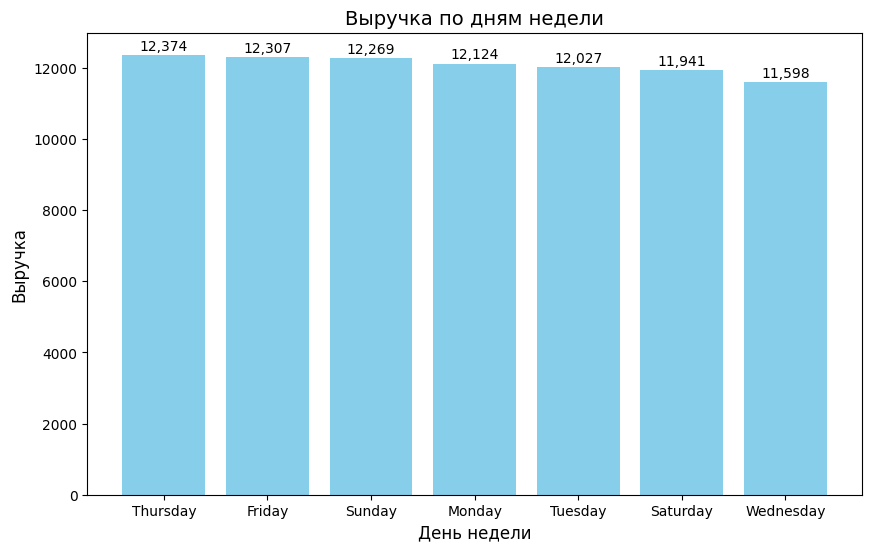

In [109]:
weekday_revenue = cafe_df.groupby('weekday')['total_spent'].sum().sort_values(ascending=False).reset_index()
print(f'Выручка по дням недели:\n\n{weekday_revenue}')

plt.figure(figsize=(10, 6))
bars = plt.bar(weekday_revenue['weekday'], weekday_revenue['total_spent'], color='skyblue')
plt.title('Выручка по дням недели', fontsize=14)
plt.xlabel('День недели', fontsize=12)
plt.ylabel('Выручка', fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)
plt.show()

Анализ распределения выручки по дням недели показал, что наиболее прибыльными днями являются четверг, пятница и воскресенье. Высокие показатели в пятницу и воскресенье объясняются поведенческими паттернами посетителей. Четверг как лидер может быть связан с локальными особенностями или проведением регулярных мероприятий. Наименьшая выручка зафиксирована в среду.
В дни с максимальной выручкой рекомендуется усиливать смены дополнительным персоналом, а в среду — проводить акции для стимулирования спроса (скидки, "счастливые часы" или специальные предложения). Относительно равномерное распределение выручки свидетельствует о стабильном потоке посетителей в течение всей недели.

## 17. Выручка по месяцам

Далее анализируется помесячная динамика выручки. Это позволяет увидеть сезонные пики и спады, которые важны для планирования закупок, меню и маркетинговых кампаний.

Выручка по месяцам:

        month  total_spent
0        June       7350.0
1     October       7295.0
2     January       7219.0
3       March       7190.5
4       April       7168.0
5    December       7153.0
6      August       7049.5
7    November       6957.0
8         May       6916.5
9        July       6876.5
10  September       6842.0
11   February       6626.0


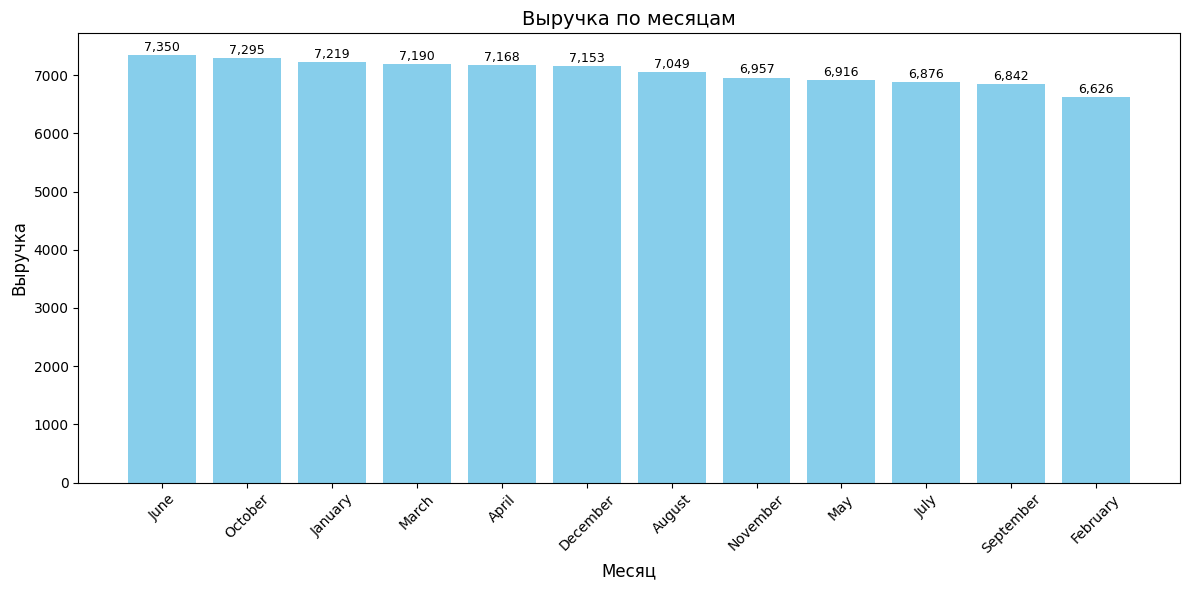

In [112]:
month_revenue = cafe_df.groupby('month')['total_spent'].sum().sort_values(ascending=False).reset_index()
print(f'Выручка по месяцам:\n\n{month_revenue}')

plt.figure(figsize=(12, 6))
bars = plt.bar(month_revenue['month'], month_revenue['total_spent'], color='skyblue')
plt.title('Выручка по месяцам', fontsize=14)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Выручка', fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'{int(height):,}', ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Лидером по выручке стал июнь с показателем 7350 у.е., за ним следуют октябрь (7295 у.е.) и январь (7219 у.е.). Высокие показатели в июне объясняются началом летнего сезона, когда люди больше времени проводят вне дома, а октябрь традиционно связан с возвращением к активной городской жизни после отпусков. Январь, несмотря на праздничные каникулы, демонстрирует устойчивый спрос за счёт новогодних встреч и выходных дней. Наименьшая выручка зафиксирована в феврале — 6626, что на 9,8% ниже показателя июня, что объясняется как короткой продолжительностью месяца, так и постпраздничным затишьем.

Постепенное снижение выручки в середине лета (июль, август) после июньского пика может быть связано с массовыми отпусками и отъездом постоянных посетителей из города. Осенние месяцы показывают стабильно высокие результаты, особенно октябрь.

В месяцы с прогнозируемо высокой выручкой (июнь, октябрь, январь) целесообразно увеличивать объёмы закупок и усиливать штат персонала. В сезон с низкой выручкой(февраль, сентябрь) можно проводить маркетинговые акции для стимулирования спроса, а также планировать технические работы или обучение сотрудников в периоды минимальной нагрузки.

## 18. Сезонный анализ

Для сезонного анализа месяцы группируются по временам года, а далее считаются агрегированные показатели, такие как суммарная выручка, средний чек и количество продаж.

In [113]:
def get_season(x):
  if x in ['December', 'January', 'February']:
    return 'winter'
  elif x in ['March', 'April', 'May']:
    return 'spring'
  elif x in ['June', 'July', 'August']:
    return 'summer'
  else:
    return 'autumn'

cafe_df['season'] = cafe_df['month'].apply(get_season)

seasonal_stats = cafe_df.groupby('season').agg({'total_spent': ['sum', 'mean', 'count'], 'quantity': 'sum'}).sort_values(('total_spent', 'sum'), ascending=False)

seasonal_stats

total_spent                 quantity
               sum      mean count      sum
season                                     
autumn     25251.5  8.841562  2856   8633.0
summer     21276.0  8.857619  2402   7193.0
spring     21275.0  9.011012  2361   7158.0
winter     20998.0  9.039173  2323   7098.0

Анализ сезонности показывает, что наибольшая суммарная выручка приходится на осень — 25251, что на 18,6% выше показателя зимы. Осень традиционно является периодом деловой активности после летних отпусков, что увеличивает посещаемость кофейни.
Примечательно, что самый высокий средний чек зафиксирован зимой (9,04 у.е.) при минимальном количестве транзакций (2323). Это может указывать на то, что зимой посетители чаще делают более крупные заказы, возможно, согревающие напитки и сытные позиции. Лето и весна демонстрируют практически идентичные показатели как по выручке, так и по количеству покупок, что говорит о стабильности спроса в тёплое время года.

## Итоги и выводы

### Качество данных
- Исходный датасет содержал значения `ERROR` и `UNKNOWN` в числовых, текстовых и датовых полях
- С помощью арифметической зависимости `total_spent = quantity × price_per_unit` удалось восстановить значительную часть числовых пропусков без потери строк
- Пропуски в названиях товаров частично восстановлены через уникальную цену товара

### Бизнес-инсайты
- Выявлены топ-товары как по объёму продаж, так и по выручке
- Определены наиболее доходные дни недели и месяцы — основа для планирования акций и ресурсов
- Сезонный анализ показал различия в поведении покупателей в разные времена года